In [1]:
!pip install llama-index-core \
    llama-index-llms-openai \
    llama-index-readers-file \
    llama-index-readers-web

!pip install unstructured[pdf,docx,pptx] \
    paddleocr \
    pillow 

!pip install trafilatura \
    cohere \
    pypdf \
    python-pptx

!pip install sentence-transformers \
    rank_bm25
!pip install llama-index-embeddings-openai
!pip install llama-index-vector-stores-faiss
!pip install llama-index
!pip install faiss-cpu
!pip install fitz
!pip install frontend

  Using cached fitz-0.0.1.dev2-py2.py3-none-any.whl.metadata (816 bytes)
Using cached fitz-0.0.1.dev2-py2.py3-none-any.whl (20 kB)
  Using cached frontend-0.0.3-py3-none-any.whl.metadata (847 bytes)
Using cached frontend-0.0.3-py3-none-any.whl (32 kB)


`LlamaIndex` 是一个用于 `LLM` 应用程序的数据框架。
主要包含以下模块：

• **Data connectors（数据连接器）：** 用于从各种数据源（如数据库、API、文件系统等）提取和加载数据，以便进行索引和查询。

• **Data indexes（数据索引）：** 负责对文档分chunk，向量化表示，为每个chunk提取元信息（关键词）等，存储已提取的数据并建立索引，以支持高效的信息检索和查询优化。

• **Query Engines（引擎）：** 执行查询处理、语义搜索、RAG（检索增强生成）等任务，确保数据的高效利用和交互。

• **Data agents（数据代理）：** 智能化的数据处理组件，可自动执行任务，如数据转换、合并、增强或基于上下文进行推理。

• **Application integrations（应用集成）：** 提供与外部应用（如LLMs、BI工具、SaaS平台等）的接口，确保数据与现有系统无缝交互。

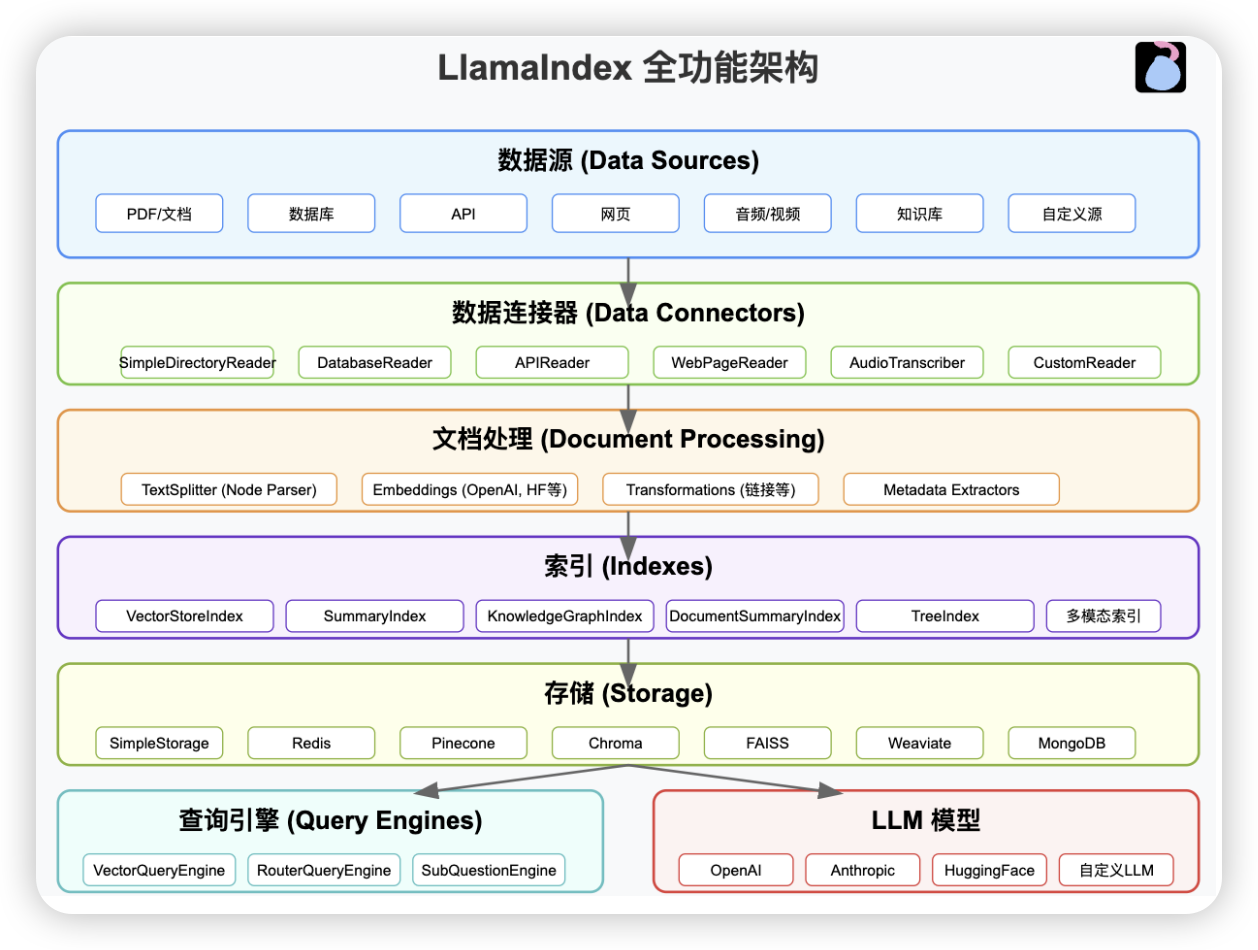

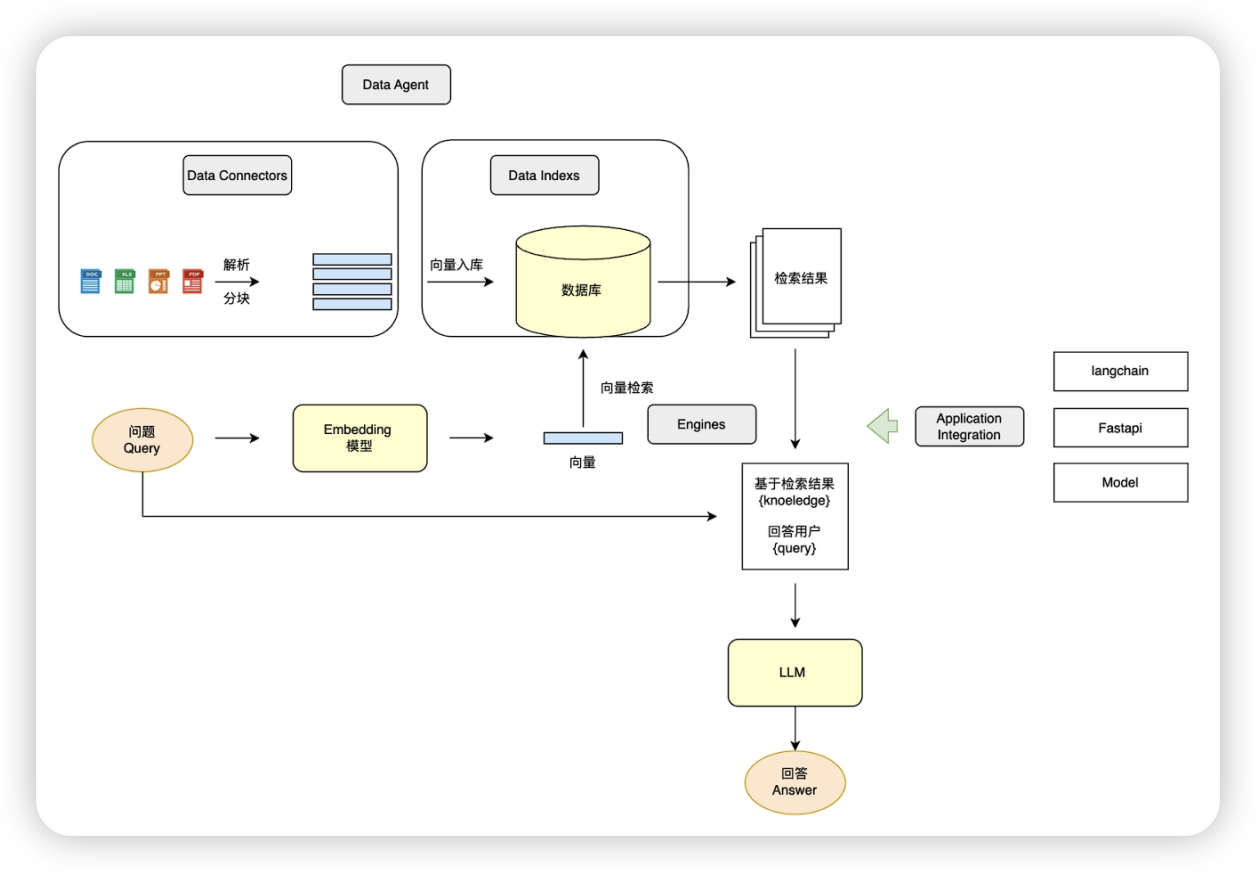

In [20]:
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')
llama_cloud_api = userdata.get('LLAMA_CLOUD_API')

In [21]:
import os
os.environ['OPENAI_API_KEY'] = openai_api_key
# llamaindex 内嵌的默认模型是gpt-3.5
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader
#文档解析
documents = SimpleDirectoryReader('data').load_data()
#构建索引
index = VectorStoreIndex.from_documents(documents)
#构建引擎
query_engine = index.as_query_engine()
#得到结果
response = query_engine.query("收盘价多少")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [4]:
response

Response(response='The closing price is 36.37 yuan.', source_nodes=[NodeWithScore(node=TextNode(id_='dd3f2801-3da5-4f47-9af7-3032a07d033f', embedding=None, metadata={'page_label': '1', 'file_name': '同仁堂研报.pdf', 'file_path': '/content/data/同仁堂研报.pdf', 'file_type': 'application/pdf', 'file_size': 2786710, 'creation_date': '2026-06-09', 'last_modified_date': '2026-06-09'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1d43fab6-7730-480a-bcca-fc55630b01fb', node_type='4', metadata={'page_label': '1', 'file_name': '同仁堂研报.pdf', 'file_path': '/content/data/同仁堂研报.pdf', 'file_type': 'application/pdf', 'file_size': 2786710, 'creation_date': '2026-06-09', 'last_modified_date': '2026-06-09'}, hash='3c00fd57d6f248f569

In [6]:
from llama_index.core import SimpleDirectoryReader
from llama_index.readers.file import PyMuPDFReader
from llama_index.readers.web import BeautifulSoupWebReader
import fitz  # provided by pymupdf

# 本地文件加载器
local_loader = SimpleDirectoryReader(
    input_dir="data",
    required_exts=[".pdf", ".docx", ".pptx", ".equb", ".md"],
    file_extractor={
        ".pdf": PyMuPDFReader(),     # 带文本坐标信息
    }
)

# 网页加载器
web_loader = BeautifulSoupWebReader()

# 示例混合加载
local_docs = local_loader.load_data()
web_docs = web_loader.load_data(urls=[
    "https://cloud.tencent.com/developer/article/2499999?fromSource=gwzcw.9358214.9358214.9358214&utm_medium=cpc&utm_id=gwzcw.9358214.9358214.9358214"
])
documents = local_docs + web_docs

Failed to load file /content/data/2024年大模型产业发展报告.pdf with error: module 'fitz' has no attribute 'open'. Skipping...
Failed to load file /content/data/【兴证电子】世运电路2023中报点评.pdf with error: module 'fitz' has no attribute 'open'. Skipping...
Failed to load file /content/data/同仁堂研报.pdf with error: module 'fitz' has no attribute 'open'. Skipping...


In [7]:
documents

[Document(id_='bebcda72-1c7d-4f0c-a2a1-f8182c7af241', embedding=None, metadata={'URL': 'https://cloud.tencent.com/developer/article/2499999?fromSource=gwzcw.9358214.9358214.9358214&utm_medium=cpc&utm_id=gwzcw.9358214.9358214.9358214'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='玩真的！人人有礼！@你的 AI 编码搭子，满血开发拿鹅厂周边~-腾讯云开发者社区-腾讯云CodeBuddy玩真的！人人有礼！@你的 AI 编码搭子，满血开发拿鹅厂周边~原创关注作者腾讯云开发者社区文档建议反馈控制台登录/注册首页学习活动专区圈层工具MCP广场文章/答案/技术大牛搜索搜索关闭发布CodeBuddy社区首页 >专栏 >玩真的！人人有礼！@你的 AI 编码搭子，满血开发拿鹅厂周边~玩真的！人人有礼！@你的 AI 编码搭子，满血开发拿鹅厂周边~原创CodeBuddy关注发布于 2025-02-26 10:35:09发布于 2025-02-26 10:35:0984K17举报文章被收录于专栏：AI代码助手官方活动AI代码助手官方活动你好，我是你的智能编码助手！上周，我们将 DeepSeek R1 满血版的腾讯云AI代码助手内置到了微信开发者工具中，让微信小程序开发更简单。今天！我带着 DeepSeek R1 + 腾讯周边礼物来了即日起，只要在「 Visual Studio Code 、JetBrains IDEs、Visual Studio、微信开发者工具」任意 IDE 中体验 DeepSeek 均有机会获奖，以下是活动详情。参与时间\xa02025年2月25日-2025年3月10日活动福利\x

In [8]:
# 异步解析
import nest_asyncio
nest_asyncio.apply()

from llama_cloud_services import LlamaParse
parser = LlamaParse(
    api_key=llama_cloud_api,
    result_type="markdown",
    num_workers=3,
    verbose=True,
    language="ch_sim",
)

file_extractor = {".pdf": parser} # 用 parser 对象去分析 .pdf 文件
documents_cloud = SimpleDirectoryReader(
    "./data", file_extractor=file_extractor
).load_data()


/tmp/ipykernel_19602/91690054.py:5: DeprecationWarning: This package (llama-cloud-services) is deprecated and will be maintained until May 1, 2026. Please migrate to the new package: pip install llama-cloud>=1.0 (https://github.com/run-llama/llama-cloud-py). The new package provides the same functionality with improved performance and support.
  from llama_cloud_services import LlamaParse
INFO:httpx:HTTP Request: POST https://api.cloud.llamaindex.ai/api/parsing/upload "HTTP/1.1 200 OK"


Started parsing the file under job_id 5e60598d-67e0-477d-938a-49ff3319ecd5


INFO:httpx:HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/5e60598d-67e0-477d-938a-49ff3319ecd5 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/5e60598d-67e0-477d-938a-49ff3319ecd5/result/markdown "HTTP/1.1 200 OK"


Error while parsing the file '<bytes/buffer>': Event loop is closed


INFO:httpx:HTTP Request: POST https://api.cloud.llamaindex.ai/api/parsing/upload "HTTP/1.1 200 OK"


Started parsing the file under job_id 462964da-762d-4c0b-ba0a-6eda33c61157


INFO:httpx:HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/462964da-762d-4c0b-ba0a-6eda33c61157 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/462964da-762d-4c0b-ba0a-6eda33c61157/result/markdown "HTTP/1.1 200 OK"


## **Data Indexes**

### **1. Chunking**

In [9]:
"""
把整篇文档切分成一个个小块（chunks/nodes）
------------------------------------
完整文档
  └─ 按 \n\n 切成段落
       ├─ 段落 ≤256 token → 直接作为一个块（可能合并相邻小段落，凑近256）
       └─ 段落 >256 token → 继续按句子切
                              └─ 句子仍超长 → 按更细标点/词切
                              （过程中遇到 <table>…</table> 整体保留）
  └─ 各块互重叠（overlap=50）
"""
from llama_index.core.node_parser import SentenceSplitter

# 设置 overlap 参数
splitter = SentenceSplitter(
    chunk_size=256,
    chunk_overlap=50,
    paragraph_separator="\n\n",   # 确保段落分隔符不会切分表格
    secondary_chunking_regex="<table>(.+?)</table>",  # 识别表格标签
    tokenizer=None
)

nodes = splitter.get_nodes_from_documents(documents)

### **3. Indexing**

llamaindex内置的数据库检索效率比较低，使用向量数据库能提供更精确的检索结果。下面给出了使用Faiss向量数据库的例子

In [15]:
"""
nodes ──向量化──> FAISS索引 ──> 向量索引 ──> 检索器 ──> 查询引擎 ──> 答案
                                                  ↑
                                          用户问题（向量化后比对）
"""
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

# 修改大模型和embedding模型设置
Settings.llm = OpenAI(model="gpt-4o")
Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small")


import faiss
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.vector_stores.faiss import FaissVectorStore

# 假设 nodes 是你已经准备好的节点列表

# 1. 创建 FAISS 索引
d = 1536  # 对应于 text-embedding-3-small 的维度
faiss_index = faiss.IndexFlatL2(d)
vector_store = FaissVectorStore(faiss_index=faiss_index)

# 2. 创建存储上下文
storage_context = StorageContext.from_defaults(vector_store=vector_store)

# 3. 使用 FAISS 向量存储创建 向量索引
vector_index = VectorStoreIndex(
    nodes=nodes,
    storage_context=storage_context,
)

# 4. 创建向量检索器
vector_retriever = VectorIndexRetriever(
    index=vector_index,
    similarity_top_k=5,
)

# 5. 创建查询引擎
query_engine = RetrieverQueryEngine.from_args(
    retriever=vector_retriever,
)

# 6. 执行查询
response = query_engine.query("同仁堂安宫牛黄丸市场的价格是多少？请你使用中文回答。")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


如果检索效果不理想, 还可以查看检索到的内容做 debug

In [16]:
# 查看检索的结果
retrieved_nodes = vector_retriever.retrieve("同仁堂安宫牛黄丸市场的价格是多少？请你使用中文回答。")

# 7. 查看检索到的节点
print(f"共检索到 {len(retrieved_nodes)} 个节点")
for i, node in enumerate(retrieved_nodes):
  print(f"\n节点 {i+1}:")
  print(f"相似度得分: {node.score}")
  print(f"内容: {node.node.text}")
  print("-" * 50)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


共检索到 5 个节点

节点 1:
相似度得分: 1.4896031618118286
内容: 责声明联系我们友情链接MCP广场开源版权声明腾讯云开发者扫码关注腾讯云开发者领取腾讯云代金券热门产品域名注册云服务器区块链服务消息队列网络加速云数据库域名解析云存储视频直播热门推荐人脸识别腾讯会议企业云CDN加速视频通话图像分析MySQL 数据库SSL
--------------------------------------------------

节点 2:
相似度得分: 1.502957820892334
内容: 阅读领券社区技术文章技术问答技术沙龙技术视频学习中心技术百科技术专区活动自媒体同步曝光计划邀请作者入驻自荐上首页技术竞赛圈层腾讯云最具价值专家腾讯云架构师技术同盟腾讯云创作之星腾讯云TDP关于社区规范免责声明联系我们友情链接MCP广场开源版权声明腾讯云开发者扫码关注腾讯云开发者领取
--------------------------------------------------

节点 3:
相似度得分: 1.5156664848327637
内容: ：本文系作者授权腾讯云开发者社区发表，未经许可，不得转载。如有侵权，请联系 cloudcommunity@tencent.com 删除。腾讯云代码助手原创声明：本文系作者授权腾讯云开发者社区发表，未经许可，不得转载。如有侵权，请联系 cloudcommunity@tencent.com 删除。腾讯云代码助手评论登录后参与评论0 条评论热度最新登录 后参与评论推荐阅读领券社区技术文章技术问答技术沙龙技术视频学习中心技术百科技术专区活
--------------------------------------------------

节点 4:
相似度得分: 1.5293394327163696
内容: 号昵称、手机号填写至抽奖小程序即可领奖扫码抽奖：点击立即抽奖，成功获奖后需要将你的分享截图、分享内容、分享平台及联系方式填写至问卷中，以便于我们联系你。 联系我们如有问题可以在用户群或者随时公众号后台私信联系我们～原创声明：本文系作者授权腾讯云开发者社区发表，未经许可，不得转载。如有侵权，请联系 cloudcommunity@tencent.com
--------------------------

### **2. Query Engines**

主要功能是处理用户查询，并通过索引和检索机制返回最佳匹配结果。

- **Query Routing：** 将query引导到最相关的知识库检索

- **Query Rewriting：** 对query进行多角度重写，去除问题中可能的违法信息

- **Query Planning：** 拆分复杂的问题，规划处解决问题的思路，逐步进行检索

**查询规划：拆分复杂问题**

`from llama_index.core.query_engine import SubQuestionQueryEngine`

**查询路由：多库选择**

`from llama_index.core.query_engine import RouterQueryEngine`

**查询重写：HyDE**

`from llama_index.core.indices.query.query_transform import HyDEQueryTransform`

In [19]:
"""
chat_engine.chat(问题)
   └─> 内部的 retriever.retrieve(问题)        ← chat engine 调用它持有的检索器
         └─> vector_index 用 embed_model 把问题转成向量
               └─> 在 FAISS 中做相似度比对，取出 top-k 片段
   └─> 把检索到的片段 + memory + system_prompt 一起给 GPT-4o
   └─> 返回答案
"""

from llama_index.core.memory import ChatMemoryBuffer

memory = ChatMemoryBuffer.from_defaults(token_limit=5000)   # 创建一个"对话记忆缓冲区"，用来保存历史对话（用户问了什么、机器人答了什么）


# Tip: index = VectorStoreIndex.from_documents(documents)
chat_engine = index.as_chat_engine(
    chat_mode="context",
    memory=memory,
    system_prompt=(
        "你是一个聊天机器人"
        "要基于检索回来的信息回答问题，如果没有检索回来信息，根据你自身的能力回答，不要不回答问题"
    ),
)

response = chat_engine.chat("詹姆斯是谁?")
response1 = chat_engine.chat("世运电路2023年上半年实现营业收入多少?")

print(response)
print('-'*60)
print(response1)
print('-'*60)
response1 = chat_engine.chat("你可以告诉我更多吗？")    # 当前模式实现了 -> 对话式对话!
print(response1)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


詹姆斯可能指的是多个知名人物，其中最著名的是勒布朗·詹姆斯（LeBron James），他是一名美国职业篮球运动员，被认为是NBA历史上最伟大的球员之一。此外，还有其他名为詹姆斯的人，如作家詹姆斯·乔伊斯（James Joyce）或演员詹姆斯·迪恩（James Dean）。具体指哪位詹姆斯需要根据上下文来判断。
------------------------------------------------------------
世运电路2023年上半年实现营业收入21.51亿元。
------------------------------------------------------------


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


关于世运电路2023年上半年的财务表现，除了实现营业收入21.51亿元外，具体的利润、成本、市场表现等详细信息通常需要查阅公司的财报或相关的新闻报道。如果你对某个特定方面感兴趣，比如利润情况、市场策略或产品发展等，可以进一步说明，我会尽力提供相关信息。


## **Data Agents**

结合大模型（LLM）和工具（工具链、API）来执行复杂任务，如自动化推理、代码执行、任务分解
等

In [24]:
"""
llm.predict_and_call([vector_query_tool, summary_tool], 问题)
   │
   └─> 大模型读取两个工具的 name / 参数 / description
         └─> 结合问题意图，决定调用哪个工具、填什么参数   ← 路由决策（对应 Query Routing）
   │
   ├─【岔路 A：选中 vector_tool，事实型问题，如"世运电路同比增长"】
   │     └─> 执行 vector_query(query, page_numbers)
   │           └─> vector_index.as_query_engine(similarity_top_k=5)
   │                 └─> embed_model 把问题转成向量
   │                       └─> 在 FAISS 中做相似度比对，取出 top-5 片段
   │                             └─> 片段 + 问题 给 GPT-4o 生成答案
   │                 （注：page_numbers 未传入 query_engine，过滤实际未生效）
   │
   └─【岔路 B：选中 summary_tool，总结型问题，如"总结一下兴证电子"】
         └─> 执行 summary_query_engine.query(query)
               └─> SummaryIndex 不做相似度检索，遍历所有 nodes
                     └─> 以 tree_summarize 模式逐层归纳（use_async 并发处理）
                           └─> 汇总结果 给 GPT-4o 生成总结
   │
   └─> 被选中工具的返回结果，作为最终 response 返回
"""
import nest_asyncio
nest_asyncio.apply()
from typing import List
from llama_index.core.vector_stores import FilterCondition
from llama_index.core.tools import FunctionTool
from llama_index.core.vector_stores import MetadataFilters

def vector_query(
    query: str,
    page_numbers: List[str]
) -> str:
     matadata_dicts = [
         {"key": "page_label", "value": p} for  p in page_numbers
     ]

     query_engine = vector_index.as_query_engine(
         similarity_top_k=5,
     )
     response = query_engine.query(query)
     return response

# Tool-1
vector_query_tool = FunctionTool.from_defaults(
    name="vector_tool",
    fn=vector_query,
)

from llama_index.core import SummaryIndex
from llama_index.core.tools import QueryEngineTool

summary_index = SummaryIndex(nodes)
summary_query_engine = summary_index.as_query_engine(
    response_mode="tree_summarize",
    use_async=True,
)

# Tool-2
summary_tool = QueryEngineTool.from_defaults(
    name="summary_tool",
    query_engine=summary_query_engine,
    description=(
        "Useful if you want to get a summary of this article"
    ),
)

llm=Settings.llm
response3 = llm.predict_and_call(
    [vector_query_tool, summary_tool],
    "总结一下兴证电子",
    verbose=True
)

llm=Settings.llm
response3 = llm.predict_and_call(
    [vector_query_tool, summary_tool],
    "世运电路2023年同比增长",
    verbose=True
)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: summary_tool with args: {"input": "\u5174\u8bc1\u7535\u5b50"}


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== Function Output ===
The provided context does not contain any information about "兴证电子."


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== Calling Function ===
Calling function: vector_tool with args: {"query": "\u4e16\u8fd0\u7535\u8def2023\u5e74\u540c\u6bd4\u589e\u957f", "page_numbers": []}


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== Function Output ===
The provided context does not contain specific information about the year-on-year growth of 世运电路 (Shiyun Circuit) for 2023.
